# Conditional GNN-GAN — L1 Matrix + Random Noise → New Graph

This notebook uses the attached 5000-sample augmented CSV.

### Generator
Input is **only**:
1. the input `l1_matrix`
2. random latent noise `Z`

The Generator uses a GNN encoder on the supplied L1 graph and noise-conditioned node embeddings, then predicts one new adjacency matrix.

### Discriminator
Input is **only**:
1. a candidate graph matrix
2. `original_vertex_permutation`

For training:
- Real = `[real L1 matrix, original_vertex_permutation]`
- Fake = `[generated graph, same original_vertex_permutation]`

The Generator therefore learns to generate a graph conditioned on the supplied L1 input.
\n\n### Final verification\nFor every generated graph G', the notebook also computes planarity and exact chromatic number for G', applies the stored original vertex permutation to obtain pi(G'), checks its planarity, forms G' union pi(G'), and computes union planarity and exact chromatic number. All generated candidates are retained in the output CSV.\n

In [1]:
# ============================================================
# 1. INSTALL / IMPORTS
# ============================================================
# No torch-geometric is required. The GNN layers below are implemented
# directly in PyTorch so the notebook is easier to run in Colab.

import os
import re
import math
import random
import json
import time
from itertools import combinations

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("Device:", DEVICE)


PyTorch: 2.11.0+cpu
Device: cpu


In [2]:
# ============================================================
# 2. SETTINGS
# ============================================================

INPUT_FILE = "augmented_5000_planar_permutation_results.csv"

MAX_NODES = 16
LATENT_DIM = 128
HIDDEN_DIM = 128
NUM_GNN_LAYERS = 4

BATCH_SIZE = 32
EPOCHS = 300
LR_G = 2e-4
LR_D = 2e-4
BETAS = (0.0, 0.9)

GP_LAMBDA = 10.0
N_CRITIC = 3

LAMBDA_EDGE_COUNT = 10.0
LAMBDA_DEGREE = 5.0
LAMBDA_CONDITION = 5.0
LAMBDA_DIVERSITY = 0.5

NUM_GENERATION_ATTEMPTS = 5000
GEN_TEMPERATURE = 0.65

OUTPUT_ALL = "Conditional_GNN_GAN_ALL_GENERATED.csv"
MODEL_FILE = "Conditional_GNN_GAN_L1_Noise.pt"

print("Input:", INPUT_FILE)
print("Device:", DEVICE)


Input: augmented_5000_planar_permutation_results.csv
Device: cpu


In [3]:
# ============================================================
# 3. CSV PARSING
# ============================================================

df = pd.read_csv(INPUT_FILE)

required = {"l1_matrix", "original_vertex_permutation", "n"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}")

def parse_matrix(s):
    return np.asarray(
        [[int(x) for x in row.strip().split()]
         for row in str(s).split("|") if row.strip()],
        dtype=np.float32
    )

def parse_permutation(s, n):
    p = np.arange(MAX_NODES, dtype=np.int64)
    for token in str(s).split(","):
        m = re.search(r"(\d+)\s*->\s*(\d+)", token)
        if m:
            old, new = int(m.group(1)), int(m.group(2))
            if 1 <= old <= n and 1 <= new <= n:
                p[old - 1] = new - 1
    return p

l1_matrices = []
permutations = []
node_counts = []

for _, row in df.iterrows():
    n = int(row["n"])
    if n > MAX_NODES:
        raise ValueError(f"n={n} exceeds MAX_NODES={MAX_NODES}")

    M = parse_matrix(row["l1_matrix"])
    if M.shape != (n, n):
        raise ValueError(f"Bad L1 matrix shape {M.shape} for n={n}")

    padded = np.zeros((MAX_NODES, MAX_NODES), dtype=np.float32)
    padded[:n, :n] = M
    l1_matrices.append(padded)

    permutations.append(parse_permutation(row["original_vertex_permutation"], n))
    node_counts.append(n)

l1_matrices = np.stack(l1_matrices)
permutations = np.stack(permutations)
node_counts = np.asarray(node_counts, dtype=np.int64)

print("Rows:", len(df))
print("L1 tensor:", l1_matrices.shape)
print("Permutation tensor:", permutations.shape)
print("Node distribution:", pd.Series(node_counts).value_counts().sort_index().to_dict())


Rows: 5000
L1 tensor: (5000, 16, 16)
Permutation tensor: (5000, 16)
Node distribution: {12: 260, 13: 1300, 14: 2093, 15: 507, 16: 840}


In [4]:
# ============================================================
# 4. CONDITIONAL DATASET
# ============================================================

class ConditionalGraphDataset(Dataset):
    def __init__(self, l1, perm, counts):
        self.l1 = torch.tensor(l1, dtype=torch.float32)
        self.perm = torch.tensor(perm, dtype=torch.long)
        self.counts = torch.tensor(counts, dtype=torch.long)

    def __len__(self):
        return len(self.l1)

    def __getitem__(self, i):
        return self.l1[i], self.perm[i], self.counts[i]

dataset = ConditionalGraphDataset(l1_matrices, permutations, node_counts)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

print("Training samples:", len(dataset))


Training samples: 5000


In [5]:
# ============================================================
# 5. GNN BUILDING BLOCKS
# ============================================================

class GraphConv(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.self_lin = nn.Linear(in_dim, out_dim)
        self.msg_lin = nn.Linear(in_dim, out_dim)
        self.norm = nn.LayerNorm(out_dim)

    def forward(self, x, A):
        deg = A.sum(-1, keepdim=True).clamp_min(1.0)
        msg = torch.bmm(A, x) / deg
        return F.gelu(self.norm(self.self_lin(x) + self.msg_lin(msg)))

def node_mask(counts):
    ids = torch.arange(MAX_NODES, device=counts.device)[None, :]
    return (ids < counts[:, None]).float()

PAIRS = list(combinations(range(MAX_NODES), 2))
print("Candidate undirected edges:", len(PAIRS))


Candidate undirected edges: 120


In [6]:
# ============================================================
# 6. GENERATOR ENCODING
# ============================================================

class L1Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.node_id = nn.Embedding(MAX_NODES, 32)
        self.input = nn.Linear(33, HIDDEN_DIM)
        self.convs = nn.ModuleList(
            [GraphConv(HIDDEN_DIM, HIDDEN_DIM) for _ in range(NUM_GNN_LAYERS)]
        )

    def forward(self, l1, counts):
        B = l1.size(0)
        ids = torch.arange(MAX_NODES, device=l1.device)[None, :].expand(B, -1)
        degree = l1.sum(-1, keepdim=True)
        x = torch.cat([self.node_id(ids), degree], dim=-1)
        h = F.gelu(self.input(x))
        mask = node_mask(counts)
        A = l1 * mask[:, :, None] * mask[:, None, :]
        for conv in self.convs:
            h = conv(h, A)
        return h


In [7]:
# ============================================================
# 7. CONDITIONAL GNN GENERATOR
# ============================================================

class GNNGenerator(nn.Module):
    # Inputs: L1 adjacency matrix + random noise.
    # Output: one new graph adjacency matrix.
    def __init__(self):
        super().__init__()
        self.encoder = L1Encoder()
        self.z_to_node = nn.Linear(LATENT_DIM, HIDDEN_DIM)
        self.fuse = nn.Linear(HIDDEN_DIM * 2, HIDDEN_DIM)
        self.convs = nn.ModuleList(
            [GraphConv(HIDDEN_DIM, HIDDEN_DIM) for _ in range(NUM_GNN_LAYERS)]
        )
        self.edge_mlp = nn.Sequential(
            nn.Linear(HIDDEN_DIM * 2, HIDDEN_DIM),
            nn.GELU(),
            nn.Linear(HIDDEN_DIM, 1)
        )

    def forward(self, l1, z, counts, tau=1.0, hard=False):
        h = self.encoder(l1, counts)
        znode = self.z_to_node(z)[:, None, :].expand(-1, MAX_NODES, -1)
        h = F.gelu(self.fuse(torch.cat([h, znode], dim=-1)))

        mask = node_mask(counts)
        A = l1 * mask[:, :, None] * mask[:, None, :]
        for conv in self.convs:
            h = conv(h, A)

        logits = []
        for i, j in PAIRS:
            logits.append(
                self.edge_mlp(torch.cat([h[:, i], h[:, j]], dim=-1)).squeeze(-1)
            )
        logits = torch.stack(logits, dim=1)

        probs = torch.sigmoid(logits / tau)
        if hard:
            probs = (probs > 0.5).float()
        return logits, probs


In [8]:
# ============================================================
# 8. CONDITIONAL GNN DISCRIMINATOR
# ============================================================

class GNNDiscriminator(nn.Module):
    # Inputs: candidate graph matrix + original_vertex_permutation.
    def __init__(self):
        super().__init__()
        self.node_id = nn.Embedding(MAX_NODES, 32)
        self.perm_emb = nn.Embedding(MAX_NODES, 32)
        self.input = nn.Linear(65, HIDDEN_DIM)
        self.convs = nn.ModuleList(
            [GraphConv(HIDDEN_DIM, HIDDEN_DIM) for _ in range(NUM_GNN_LAYERS)]
        )
        self.readout = nn.Sequential(
            nn.Linear(HIDDEN_DIM, HIDDEN_DIM),
            nn.GELU(),
            nn.Linear(HIDDEN_DIM, 1)
        )

    def forward(self, graph, perm, counts, return_features=False):
        B = graph.size(0)
        ids = torch.arange(MAX_NODES, device=graph.device)[None, :].expand(B, -1)
        mask = node_mask(counts)

        x = torch.cat([
            self.node_id(ids),
            self.perm_emb(perm),
            graph.sum(-1, keepdim=True)
        ], dim=-1)

        h = F.gelu(self.input(x))
        A = graph * mask[:, :, None] * mask[:, None, :]

        for conv in self.convs:
            h = conv(h, A)

        h = h * mask[:, :, None]
        pooled = h.sum(1) / mask.sum(1, keepdim=True).clamp_min(1.0)
        score = self.readout(pooled).squeeze(-1)

        return (score, pooled) if return_features else score


In [9]:
# ============================================================
# 9. MODELS + HELPERS
# ============================================================

G = GNNGenerator().to(DEVICE)
D = GNNDiscriminator().to(DEVICE)

opt_G = torch.optim.Adam(G.parameters(), lr=LR_G, betas=BETAS)
opt_D = torch.optim.Adam(D.parameters(), lr=LR_D, betas=BETAS)

def vector_to_matrix(edge_probs, counts):
    B = edge_probs.size(0)
    M = torch.zeros(B, MAX_NODES, MAX_NODES, device=edge_probs.device)
    for k, (i, j) in enumerate(PAIRS):
        M[:, i, j] = edge_probs[:, k]
        M[:, j, i] = edge_probs[:, k]
    mask = node_mask(counts)
    return M * mask[:, :, None] * mask[:, None, :]

def edge_count_loss(fake, real, counts):
    mask = node_mask(counts)
    denom = (mask.sum(1) * (mask.sum(1) - 1)).clamp_min(2)
    return F.mse_loss(fake.sum((1,2)) / denom, real.sum((1,2)) / denom)

def degree_profile_loss(fake, real):
    f = torch.sort(fake.sum(-1), dim=-1).values
    r = torch.sort(real.sum(-1), dim=-1).values
    return F.mse_loss(f / MAX_NODES, r / MAX_NODES)

def gradient_penalty(real_graph, fake_graph, perm, counts):
    alpha = torch.rand(real_graph.size(0), 1, 1, device=DEVICE)
    interp = (alpha * real_graph + (1 - alpha) * fake_graph).requires_grad_(True)
    score = D(interp, perm, counts)
    grad = torch.autograd.grad(
        score, interp, torch.ones_like(score),
        create_graph=True, retain_graph=True
    )[0]
    grad = grad.reshape(grad.size(0), -1)
    return ((grad.norm(2, dim=1) - 1.0) ** 2).mean()

print("Generator parameters:", sum(p.numel() for p in G.parameters()))
print("Discriminator parameters:", sum(p.numel() for p in D.parameters()))


Generator parameters: 353537
Discriminator parameters: 159233


In [10]:
# ============================================================
# 10. CONDITIONAL TRAINING
# ============================================================

history = {"G": [], "D": [], "edge": [], "degree": [], "condition": []}

for epoch in range(1, EPOCHS + 1):
    G.train(); D.train()
    eg = ed = ee = edeg = ec = 0.0
    batches = 0

    for real_l1, perm, counts in loader:
        real_l1 = real_l1.to(DEVICE)
        perm = perm.to(DEVICE)
        counts = counts.to(DEVICE)

        # ---------------- Critic ----------------
        for _ in range(N_CRITIC):
            opt_D.zero_grad(set_to_none=True)

            z = torch.randn(real_l1.size(0), LATENT_DIM, device=DEVICE)
            _, fake_probs = G(real_l1, z, counts, tau=0.75, hard=False)
            fake_graph = vector_to_matrix(fake_probs, counts)

            # REAL: [L1 matrix] + [original_vertex_permutation]
            real_score = D(real_l1, perm, counts)

            # FAKE: [generated graph] + [same original_vertex_permutation]
            fake_score = D(fake_graph.detach(), perm, counts)

            gp = gradient_penalty(real_l1, fake_graph.detach(), perm, counts)
            d_loss = fake_score.mean() - real_score.mean() + GP_LAMBDA * gp
            d_loss.backward()
            torch.nn.utils.clip_grad_norm_(D.parameters(), 10.0)
            opt_D.step()

        # ---------------- Generator ----------------
        opt_G.zero_grad(set_to_none=True)

        z = torch.randn(real_l1.size(0), LATENT_DIM, device=DEVICE)
        _, fake_probs = G(real_l1, z, counts, tau=0.75, hard=False)
        fake_graph = vector_to_matrix(fake_probs, counts)

        fake_score, fake_features = D(fake_graph, perm, counts, return_features=True)
        with torch.no_grad():
            _, real_features = D(real_l1, perm, counts, return_features=True)

        adversarial = -fake_score.mean()
        e_loss = edge_count_loss(fake_graph, real_l1, counts)
        d_loss_struct = degree_profile_loss(fake_graph, real_l1)

        # Forces the generated graph to remain related to the supplied L1 input.
        condition_loss = F.mse_loss(fake_features, real_features)

        diversity_loss = -fake_probs.mean(0).var()

        g_loss = (
            adversarial
            + LAMBDA_EDGE_COUNT * e_loss
            + LAMBDA_DEGREE * d_loss_struct
            + LAMBDA_CONDITION * condition_loss
            + LAMBDA_DIVERSITY * diversity_loss
        )

        g_loss.backward()
        torch.nn.utils.clip_grad_norm_(G.parameters(), 10.0)
        opt_G.step()

        eg += g_loss.item()
        ed += d_loss.item()
        ee += e_loss.item()
        edeg += d_loss_struct.item()
        ec += condition_loss.item()
        batches += 1

    history["G"].append(eg / batches)
    history["D"].append(ed / batches)
    history["edge"].append(ee / batches)
    history["degree"].append(edeg / batches)
    history["condition"].append(ec / batches)

    if epoch == 1 or epoch % 10 == 0 or epoch == EPOCHS:
        print(
            f"Epoch {epoch:3d}/{EPOCHS} | "
            f"G {history['G'][-1]:.4f} | "
            f"D {history['D'][-1]:.4f} | "
            f"edge {history['edge'][-1]:.4f} | "
            f"degree {history['degree'][-1]:.4f} | "
            f"condition {history['condition'][-1]:.4f}"
        )

print("TRAINING COMPLETE")


Epoch   1/300 | G 1.9803 | D -1.5289 | edge 0.0043 | degree 0.0070 | condition 0.1046
Epoch  10/300 | G -0.0590 | D -1.7391 | edge 0.0017 | degree 0.0031 | condition 0.0466
Epoch  20/300 | G 0.1226 | D -1.8074 | edge 0.0015 | degree 0.0027 | condition 0.0615
Epoch  30/300 | G 0.1479 | D -1.9818 | edge 0.0013 | degree 0.0027 | condition 0.0713
Epoch  40/300 | G 0.3201 | D -2.1394 | edge 0.0012 | degree 0.0026 | condition 0.0779
Epoch  50/300 | G 0.6137 | D -2.2518 | edge 0.0011 | degree 0.0025 | condition 0.0830
Epoch  60/300 | G 1.1866 | D -2.3961 | edge 0.0011 | degree 0.0025 | condition 0.0998
Epoch  70/300 | G 1.3761 | D -2.4245 | edge 0.0010 | degree 0.0022 | condition 0.1082
Epoch  80/300 | G 1.5644 | D -2.4469 | edge 0.0010 | degree 0.0023 | condition 0.1166
Epoch  90/300 | G 1.9122 | D -2.4956 | edge 0.0010 | degree 0.0023 | condition 0.1283
Epoch 100/300 | G 2.1304 | D -2.4333 | edge 0.0009 | degree 0.0021 | condition 0.1349
Epoch 110/300 | G 2.2940 | D -2.4853 | edge 0.0008 | 

In [11]:
# ============================================================
# 11. SAVE CHECKPOINT
# ============================================================

torch.save({
    "generator_state_dict": G.state_dict(),
    "discriminator_state_dict": D.state_dict(),
    "settings": {
        "MAX_NODES": MAX_NODES,
        "LATENT_DIM": LATENT_DIM,
        "HIDDEN_DIM": HIDDEN_DIM,
        "NUM_GNN_LAYERS": NUM_GNN_LAYERS
    }
}, MODEL_FILE)

print("Saved:", MODEL_FILE)


Saved: Conditional_GNN_GAN_L1_Noise.pt


In [15]:
# ============================================================
# POST-TRAINING SANITY TEST - DEBUG VERSION
# ============================================================

POST_TRAIN_SANITY_SAMPLES = 10

G.eval()

idx = np.random.choice(
    len(dataset),
    size=POST_TRAIN_SANITY_SAMPLES,
    replace=True
)

batch = [dataset[int(i)] for i in idx]

l1_batch = torch.stack(
    [x[0] for x in batch]
).to(DEVICE)

counts = torch.stack(
    [x[2] for x in batch]
).to(DEVICE)

z = torch.randn(
    POST_TRAIN_SANITY_SAMPLES,
    LATENT_DIM,
    device=DEVICE
)

with torch.no_grad():

    fake_graph = G(
        l1_batch,
        z,
        counts
    )

print("=" * 70)
print("GENERATOR OUTPUT DEBUG")
print("=" * 70)

print("Type:", type(fake_graph))

if isinstance(fake_graph, tuple):
    print("Generator returned tuple of length:", len(fake_graph))

    for i, item in enumerate(fake_graph):
        print(
            f"Output {i}: "
            f"type={type(item)}, "
            f"shape={item.shape if hasattr(item, 'shape') else 'N/A'}"
        )

else:
    print(
        "Generator output shape:",
        fake_graph.shape
    )

print("=" * 70)

GENERATOR OUTPUT DEBUG
Type: <class 'tuple'>
Generator returned tuple of length: 2
Output 0: type=<class 'torch.Tensor'>, shape=torch.Size([10, 120])
Output 1: type=<class 'torch.Tensor'>, shape=torch.Size([10, 120])


In [17]:
# ============================================================
# 13. EXACT CHROMATIC NUMBER
# ============================================================

def exact_chromatic_number(edges, n):
    if n <= 0:
        return 0

    adj = [set() for _ in range(n + 1)]
    for u, v in edges:
        if 1 <= u <= n and 1 <= v <= n and u != v:
            adj[u].add(v)
            adj[v].add(u)

    if not any(adj[1:]):
        return 1

    colors = [0] * (n + 1)

    # Greedy upper bound
    temp = [0] * (n + 1)
    used = 0
    for _ in range(n):
        uncolored = [v for v in range(1, n + 1) if temp[v] == 0]
        if not uncolored:
            break
        v = max(
            uncolored,
            key=lambda x: (
                len({temp[w] for w in adj[x] if temp[w] != 0}),
                len(adj[x])
            )
        )
        forbidden = {temp[w] for w in adj[v] if temp[w] != 0}
        c = 1
        while c in forbidden:
            c += 1
        temp[v] = c
        used = max(used, c)

    upper = used

    def k_colorable(k):
        for i in range(1, n + 1):
            colors[i] = 0

        def backtrack(colored):
            if colored == n:
                return True

            uncolored = [v for v in range(1, n + 1) if colors[v] == 0]
            v = max(
                uncolored,
                key=lambda x: (
                    len({colors[w] for w in adj[x] if colors[w] != 0}),
                    len(adj[x])
                )
            )

            forbidden = {colors[w] for w in adj[v] if colors[w] != 0}

            for c in range(1, k + 1):
                if c in forbidden:
                    continue
                colors[v] = c
                if backtrack(colored + 1):
                    return True
                colors[v] = 0

            return False

        return backtrack(0)

    for k in range(1, upper + 1):
        if k_colorable(k):
            return k

    return upper


# Self-tests
K10 = {(i, j) for i in range(1, 11) for j in range(i + 1, 11)}
assert exact_chromatic_number(K10, 10) == 10
assert exact_chromatic_number(set(), 5) == 1

print("Chromatic-number self-test PASSED")
print("K10:", exact_chromatic_number(K10, 10))
print("Empty graph:", exact_chromatic_number(set(), 5))


Chromatic-number self-test PASSED
K10: 10
Empty graph: 1


In [18]:
# ============================================================
# 14. GRAPH VERIFICATION HELPERS
# ============================================================


def is_planar(edges, n):
    """Return True if the n-node undirected graph is planar."""
    g = nx.Graph()
    g.add_nodes_from(range(1, n + 1))
    g.add_edges_from(edges)
    return bool(nx.check_planarity(g)[0])


def edges_from_binary_matrix(matrix, n):
    """Convert an n x n binary adjacency matrix to 1-indexed edges."""
    matrix = np.asarray(matrix)
    edges = set()
    for i in range(n):
        for j in range(i + 1, n):
            if matrix[i, j] >= 0.5 or matrix[j, i] >= 0.5:
                edges.add((i + 1, j + 1))
    return edges


def parse_vertex_permutation(s, n):
    """Parse strings such as '1->4, 2->1, 3->2, 4->3'."""
    mapping = {}
    for part in str(s).split(','):
        m = re.search(r'(\d+)\s*->\s*(\d+)', part)
        if m:
            a, b = int(m.group(1)), int(m.group(2))
            if 1 <= a <= n and 1 <= b <= n:
                mapping[a] = b

    # Require a valid permutation. If the CSV has a slightly different
    # formatting, fall back to identity rather than silently creating
    # an invalid graph.
    if len(mapping) != n or set(mapping.values()) != set(range(1, n + 1)):
        raise ValueError(
            f"Invalid vertex permutation for n={n}: {s!r}. "
            f"Parsed mapping={mapping}"
        )
    return mapping


def permute_edges(edges, permutation):
    """Apply vertex relabeling a -> permutation[a] to an edge set."""
    out = set()
    for u, v in edges:
        a, b = permutation[u], permutation[v]
        if a != b:
            out.add((min(a, b), max(a, b)))
    return out


def edges_to_matrix(edges, n):
    """Create a compact integer adjacency matrix string."""
    mat = np.zeros((n, n), dtype=int)
    for u, v in edges:
        mat[u - 1, v - 1] = 1
        mat[v - 1, u - 1] = 1
    return mat


def matrix_to_string(mat):
    return "|".join(" ".join(map(str, row)) for row in np.asarray(mat))


def verify_generated_graph(edges, n, permutation):
    """Verify G', pi(G'), and G' union pi(G')."""
    permuted_edges = permute_edges(edges, permutation)
    union_edges = edges | permuted_edges

    generated_planar = is_planar(edges, n)
    permuted_planar = is_planar(permuted_edges, n)
    union_planar = is_planar(union_edges, n)

    chromatic_generated = exact_chromatic_number(edges, n)
    chromatic_permuted = exact_chromatic_number(permuted_edges, n)
    chromatic_union = exact_chromatic_number(union_edges, n)

    return {
        "permuted_edges": permuted_edges,
        "union_edges": union_edges,
        "generated_planar": generated_planar,
        "permuted_generated_planar": permuted_planar,
        "union_planar": union_planar,
        "chromatic_generated": chromatic_generated,
        "chromatic_permuted_generated": chromatic_permuted,
        "chromatic_union": chromatic_union,
    }

print("Verification helpers loaded.")
print("Each generated graph will be checked as G', pi(G'), and G' union pi(G').")


Verification helpers loaded.
Each generated graph will be checked as G', pi(G'), and G' union pi(G').


In [19]:
# ============================================================
# 15. GENERATE + VERIFY NEW GRAPHS CONDITIONED ON INPUT L1
# ============================================================

G.eval()
all_rows = []

print("=" * 80)
print("CONDITIONAL GENERATION + STRUCTURAL VERIFICATION")
print("Generator input = [L1 matrix] + [random noise]")
print("Discriminator input = [candidate graph] + [original_vertex_permutation]")
print("For every generated G':")
print("  1. Check planarity and chi(G')")
print("  2. Build pi(G') using original_vertex_permutation")
print("  3. Check planarity of pi(G')")
print("  4. Build G' union pi(G')")
print("  5. Check planarity and chi of the union")
print("Candidates:", NUM_GENERATION_ATTEMPTS)
print("=" * 80)

with torch.no_grad():
    for start in range(0, NUM_GENERATION_ATTEMPTS, BATCH_SIZE):
        b = min(BATCH_SIZE, NUM_GENERATION_ATTEMPTS - start)

        idx = np.random.randint(0, len(df), size=b)

        l1 = torch.tensor(l1_matrices[idx], dtype=torch.float32, device=DEVICE)
        perm = torch.tensor(permutations[idx], dtype=torch.long, device=DEVICE)
        counts = torch.tensor(node_counts[idx], dtype=torch.long, device=DEVICE)
        z = torch.randn(b, LATENT_DIM, device=DEVICE)

        _, probs = G(l1, z, counts, tau=GEN_TEMPERATURE, hard=True)
        generated = probs.cpu().numpy()

        for j in range(b):
            source = df.iloc[idx[j]]
            n = int(node_counts[idx[j]])

            # --------------------------------------------------------
            # Generated graph G'
            # --------------------------------------------------------
            edges = set()
            for k, (u, v) in enumerate(PAIRS):
                if u < n and v < n and generated[j, k] >= 0.5:
                    edges.add((u + 1, v + 1))

            # --------------------------------------------------------
            # Read the original vertex permutation and apply it to G'
            # --------------------------------------------------------
            permutation = parse_vertex_permutation(
                source["original_vertex_permutation"], n
            )

            # --------------------------------------------------------
            # Verification
            # --------------------------------------------------------
            result = verify_generated_graph(edges, n, permutation)
            permuted_edges = result["permuted_edges"]
            union_edges = result["union_edges"]

            generated_matrix = edges_to_matrix(edges, n)
            permuted_matrix = edges_to_matrix(permuted_edges, n)
            union_matrix = edges_to_matrix(union_edges, n)

            all_rows.append({
                "generated_id": start + j + 1,
                "source_sample_id": int(source["sample_id"]),
                "original_graph_id": source["original_graph_id"],
                "n": n,
                "input_l1_matrix": source["l1_matrix"],
                "original_vertex_permutation": source["original_vertex_permutation"],

                # G'
                "generated_edges": ", ".join(f"{u}-{v}" for u, v in sorted(edges)),
                "generated_matrix": matrix_to_string(generated_matrix),
                "generated_edge_count": len(edges),
                "generated_planar": result["generated_planar"],
                "chromatic_generated": result["chromatic_generated"],

                # pi(G')
                "permuted_generated_edges": ", ".join(
                    f"{u}-{v}" for u, v in sorted(permuted_edges)
                ),
                "permuted_generated_matrix": matrix_to_string(permuted_matrix),
                "permuted_generated_edge_count": len(permuted_edges),
                "permuted_generated_planar": result["permuted_generated_planar"],
                "chromatic_permuted_generated": result["chromatic_permuted_generated"],

                # G' union pi(G')
                "union_generated_edges": ", ".join(
                    f"{u}-{v}" for u, v in sorted(union_edges)
                ),
                "union_generated_matrix": matrix_to_string(union_matrix),
                "union_generated_edge_count": len(union_edges),
                "union_planar": result["union_planar"],
                "chromatic_union": result["chromatic_union"],

                # Convenient research filters
                "both_graphs_planar": bool(
                    result["generated_planar"] and result["permuted_generated_planar"]
                ),
                "both_planar_union_nonplanar": bool(
                    result["generated_planar"]
                    and result["permuted_generated_planar"]
                    and not result["union_planar"]
                ),
            })

        done = start + b
        if done % 100 == 0 or done == NUM_GENERATION_ATTEMPTS:
            current = pd.DataFrame(all_rows)
            planar_rate = 100 * current["generated_planar"].mean()
            union_nonplanar_rate = 100 * (~current["union_planar"]).mean()
            chi8_9 = 100 * current["chromatic_union"].isin([8, 9]).mean()
            print(
                f"{done}/{NUM_GENERATION_ATTEMPTS} generated | "
                f"G' planar={planar_rate:.2f}% | "
                f"union non-planar={union_nonplanar_rate:.2f}% | "
                f"union chi 8/9={chi8_9:.2f}%",
                flush=True
            )

print("GENERATION + VERIFICATION COMPLETE")


CONDITIONAL GENERATION + STRUCTURAL VERIFICATION
Generator input = [L1 matrix] + [random noise]
Discriminator input = [candidate graph] + [original_vertex_permutation]
For every generated G':
  1. Check planarity and chi(G')
  2. Build pi(G') using original_vertex_permutation
  3. Check planarity of pi(G')
  4. Build G' union pi(G')
  5. Check planarity and chi of the union
Candidates: 5000
800/5000 generated | G' planar=84.25% | union non-planar=100.00% | union chi 8/9=0.00%
1600/5000 generated | G' planar=83.88% | union non-planar=100.00% | union chi 8/9=0.00%
2400/5000 generated | G' planar=84.50% | union non-planar=100.00% | union chi 8/9=0.00%
3200/5000 generated | G' planar=84.16% | union non-planar=100.00% | union chi 8/9=0.00%
4000/5000 generated | G' planar=84.28% | union non-planar=100.00% | union chi 8/9=0.03%
4800/5000 generated | G' planar=84.17% | union non-planar=100.00% | union chi 8/9=0.02%
5000/5000 generated | G' planar=84.44% | union non-planar=100.00% | union chi 8

In [20]:
# ============================================================
# 16. SAVE VERIFIED GENERATED GRAPHS + SUMMARY
# ============================================================

all_df = pd.DataFrame(all_rows)
all_df.to_csv(OUTPUT_ALL, index=False)

print("=" * 80)
print("FINAL OUTPUT SUMMARY")
print("=" * 80)
print("Generated graphs:", len(all_df))
print("Saved:", OUTPUT_ALL)

if len(all_df) > 0:
    print("\nG' planar:", int(all_df["generated_planar"].sum()), "/", len(all_df))
    print("pi(G') planar:", int(all_df["permuted_generated_planar"].sum()), "/", len(all_df))
    print("Union planar:", int(all_df["union_planar"].sum()), "/", len(all_df))
    print("Union non-planar:", int((~all_df["union_planar"]).sum()), "/", len(all_df))
    print("Union chi = 8:", int((all_df["chromatic_union"] == 8).sum()))
    print("Union chi = 9:", int((all_df["chromatic_union"] == 9).sum()))
    print("Both G' and pi(G') planar + union non-planar:",
          int(all_df["both_planar_union_nonplanar"].sum()))

    print("\nChromatic-number distribution of G' / union:")
    print(pd.DataFrame({
        "G_prime_chi": all_df["chromatic_generated"].value_counts().sort_index(),
        "Union_chi": all_df["chromatic_union"].value_counts().sort_index()
    }).fillna(0).astype(int))

    print("\nFirst 5 verified samples:")
    display(all_df.head(5))


FINAL OUTPUT SUMMARY
Generated graphs: 5000
Saved: Conditional_GNN_GAN_ALL_GENERATED.csv

G' planar: 4222 / 5000
pi(G') planar: 4222 / 5000
Union planar: 0 / 5000
Union non-planar: 5000 / 5000
Union chi = 8: 1
Union chi = 9: 0
Both G' and pi(G') planar + union non-planar: 4222

Chromatic-number distribution of G' / union:
   G_prime_chi  Union_chi
3           50          0
4         4805         16
5          145       1385
6            0       3249
7            0        349
8            0          1

First 5 verified samples:


,generated_id,source_sample_id,original_graph_id,n,input_l1_matrix,original_vertex_permutation,generated_edges,generated_matrix,generated_edge_count,generated_planar,...,permuted_generated_edge_count,permuted_generated_planar,chromatic_permuted_generated,union_generated_edges,union_generated_matrix,union_generated_edge_count,union_planar,chromatic_union,both_graphs_planar,both_planar_union_nonplanar
0,1,879,ID7-13.63.2,13,0 0 0 0 1 0 0 0 1 0 0 1 0|0 0 1 1 1 0 1 0 0 0 ...,"1->1, 2->11, 3->9, 4->12, 5->5, 6->6, 7->8, 8-...","1-5, 1-9, 1-12, 2-3, 2-4, 2-5, 2-7, 3-4, 3-5, ...",0 0 0 0 1 0 0 0 1 0 0 1 0|0 0 1 1 1 0 1 0 0 0 ...,32,True,...,32,True,4,"1-2, 1-5, 1-7, 1-9, 1-12, 2-3, 2-4, 2-5, 2-7, ...",0 1 0 0 1 0 1 0 1 0 0 1 0|1 0 1 1 1 0 1 0 1 0 ...,52,False,6,True,True
1,2,1077,ID9-13.64.1:,13,0 1 1 1 1 1 0 0 0 0 0 0 0|1 0 0 1 1 1 0 0 0 1 ...,"1->8, 2->2, 3->11, 4->6, 5->5, 6->1, 7->9, 8->...","1-2, 1-3, 1-4, 1-5, 1-6, 2-4, 2-5, 2-6, 2-10, ...",0 1 1 1 1 1 0 0 0 0 0 0 0|1 0 0 1 1 1 0 0 0 1 ...,32,True,...,32,True,4,"1-2, 1-3, 1-4, 1-5, 1-6, 1-7, 1-8, 1-11, 2-4, ...",0 1 1 1 1 1 1 1 0 0 1 0 0|1 0 0 1 1 1 1 1 0 1 ...,49,False,6,True,True
2,3,4888,ID40-16.84.6:,16,0 0 0 1 0 1 0 1 0 0 1 1 0 0 1 1|0 0 0 1 0 0 0 ...,"1->1, 2->14, 3->15, 4->10, 5->5, 6->13, 7->7, ...","1-4, 1-6, 1-8, 1-11, 1-12, 1-15, 1-16, 2-4, 2-...",0 0 0 1 0 1 0 1 0 0 1 1 0 0 1 1|0 0 0 1 0 0 0 ...,42,True,...,42,True,4,"1-4, 1-6, 1-8, 1-10, 1-11, 1-12, 1-13, 1-15, 1...",0 0 0 1 0 1 0 1 0 1 1 1 1 0 1 1|0 0 1 1 0 0 0 ...,65,False,6,True,True
3,4,3994,ID32-15.78.1:,15,0 0 0 1 1 0 0 0 1 0 0 0 0 0 1|0 0 0 0 1 0 0 0 ...,"1->13, 2->2, 3->3, 4->8, 5->10, 6->1, 7->7, 8-...","1-4, 1-5, 1-9, 1-15, 2-5, 2-10, 2-12, 3-4, 3-5...",0 0 0 1 1 0 0 0 1 0 0 0 0 0 1|0 0 0 0 1 0 0 0 ...,39,True,...,39,True,4,"1-3, 1-4, 1-5, 1-8, 1-9, 1-10, 1-15, 2-5, 2-10...",0 0 1 1 1 0 0 1 1 1 0 0 0 0 1|0 0 0 0 1 0 0 0 ...,56,False,6,True,True
4,5,4860,ID39-16.84.5:,16,0 0 0 0 1 1 0 0 1 1 0 1 0 0 0 1|0 0 0 0 1 0 1 ...,"1->1, 2->11, 3->3, 4->4, 5->16, 6->9, 7->2, 8-...","1-5, 1-6, 1-9, 1-10, 1-12, 1-16, 2-5, 2-7, 2-8...",0 0 0 0 1 1 0 0 1 1 0 1 0 0 0 1|0 0 0 0 1 0 1 ...,42,True,...,42,True,4,"1-5, 1-6, 1-9, 1-10, 1-12, 1-13, 1-16, 2-5, 2-...",0 0 0 0 1 1 0 0 1 1 0 1 1 0 0 1|0 0 0 0 1 0 1 ...,64,False,6,True,True


In [21]:
# ============================================================
# 17. OPTIONAL RESEARCH FILTERS
# ============================================================

# Examples of useful subsets. Nothing is deleted from all_df.

planar_generated = all_df[all_df["generated_planar"]].copy()
planar_both = all_df[all_df["both_graphs_planar"]].copy()
chi_8_or_9_union = all_df[all_df["chromatic_union"].isin([8, 9])].copy()
planar_both_chi_8_or_9 = all_df[
    all_df["both_graphs_planar"] & all_df["chromatic_union"].isin([8, 9])
].copy()

print("Optional subsets (original all_df is unchanged):")
print("G' planar:", len(planar_generated))
print("Both G' and pi(G') planar:", len(planar_both))
print("Union chi 8 or 9:", len(chi_8_or_9_union))
print("Both planar + union chi 8 or 9:", len(planar_both_chi_8_or_9))


Optional subsets (original all_df is unchanged):
G' planar: 4222
Both G' and pi(G') planar: 4222
Union chi 8 or 9: 1
Both planar + union chi 8 or 9: 0


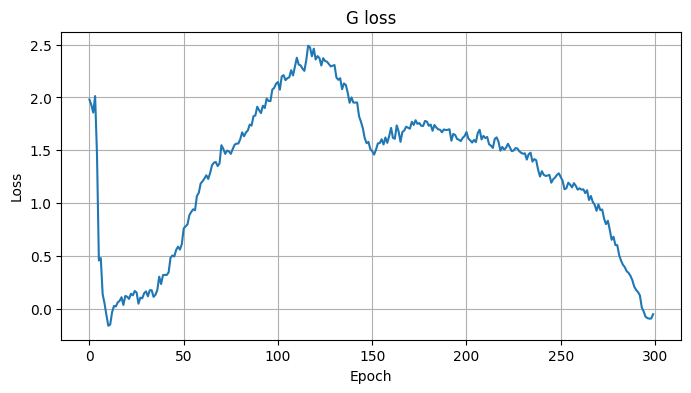

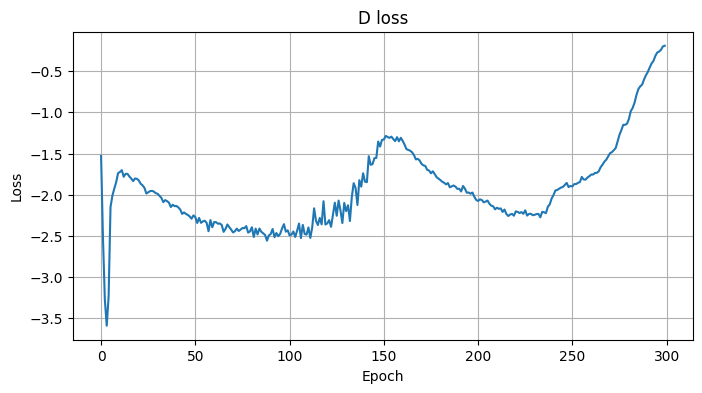

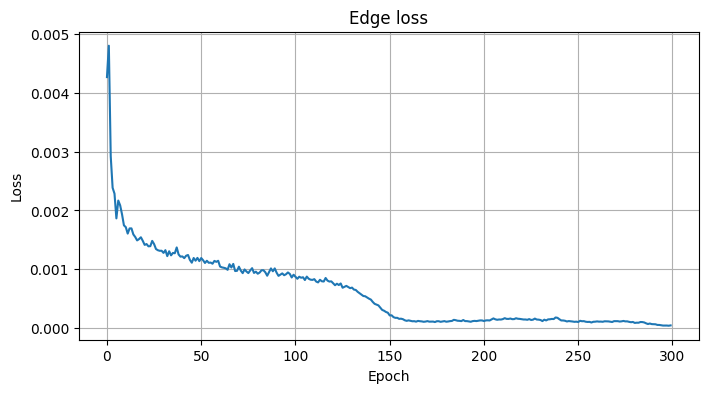

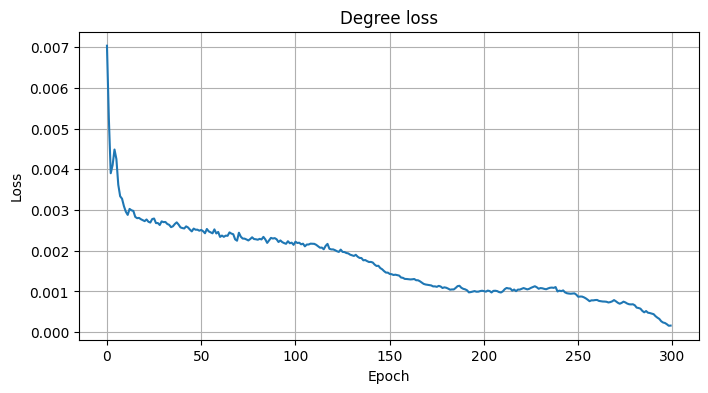

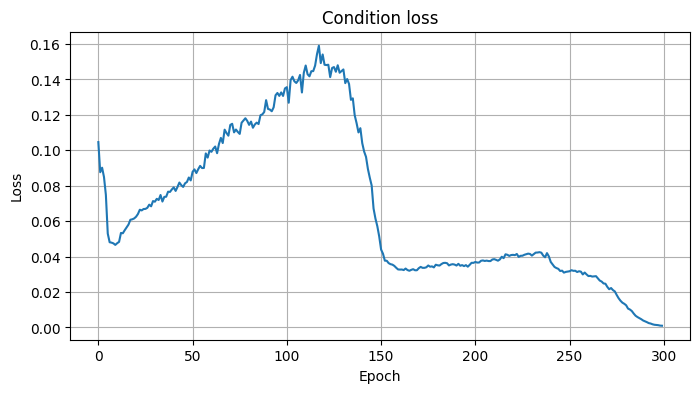

In [22]:
# ============================================================
# 18. TRAINING CURVES
# ============================================================

for title, key in [
    ("G loss", "G"),
    ("D loss", "D"),
    ("Edge loss", "edge"),
    ("Degree loss", "degree"),
    ("Condition loss", "condition")
]:
    plt.figure(figsize=(8,4))
    plt.plot(history[key])
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()


In [23]:
# ============================================================
# 19. COLAB DOWNLOAD
# ============================================================

from google.colab import files

files.download(OUTPUT_ALL)
files.download(MODEL_FILE)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
import pandas as pd

INPUT_CSV = "Conditional_GNN_GAN_ALL_GENERATED.csv"
OUTPUT_CSV = "Conditional_GNN_GAN_Chromatic_8_9.csv"

df = pd.read_csv(INPUT_CSV)

# Shortlist graphs whose UNION chromatic number is 8 or 9
shortlisted = df[
    pd.to_numeric(df["chromatic_union"], errors="coerce").isin([8, 9])
].copy()

shortlisted.to_csv(OUTPUT_CSV, index=False)

print("=" * 60)
print("SHORTLIST COMPLETE")
print("=" * 60)
print("Total generated graphs:", len(df))
print("Chromatic 8:", (shortlisted["chromatic_union"] == 8).sum())
print("Chromatic 9:", (shortlisted["chromatic_union"] == 9).sum())
print("Total shortlisted:", len(shortlisted))
print("Output file:", OUTPUT_CSV)
print("=" * 60)

SHORTLIST COMPLETE
Total generated graphs: 5000
Chromatic 8: 1
Chromatic 9: 0
Total shortlisted: 1
Output file: Conditional_GNN_GAN_Chromatic_8_9.csv


In [30]:
# ============================================================
# 50,000 GENERATED GRAPHS
# SAME 23-COLUMN FORMAT AS:
# Conditional_GNN_GAN_ALL_GENERATED(1).csv
#
# G' = Generator(L1, random noise)
# π(G') = original permutation applied to G'
# Union = G' ∪ π(G')
#
# IMPORTANT:
# Exact chromatic number and planarity are verified separately
# using the Boost verification stage.
#
# NO 0-INDEXING IN EDGE LISTS / PERMUTATIONS
# ============================================================

import os
import numpy as np
import pandas as pd
import torch


# ============================================================
# SETTINGS
# ============================================================

NUM_GENERATED = 50000
BATCH_SIZE_GEN = 64

INPUT_FILE = "augmented_5000_planar_permutation_results.csv"

OUTPUT_FILE = "Conditional_GNN_GAN_50000_ALL_GENERATED.csv"


# ============================================================
# CHECK MODEL
# ============================================================

G.eval()

print("=" * 75)
print("50,000 GRAPH GENERATION")
print("=" * 75)

print("Input file:", INPUT_FILE)
print("Input samples:", len(pd.read_csv(INPUT_FILE)))
print("Graphs to generate:", NUM_GENERATED)
print("Batch size:", BATCH_SIZE_GEN)
print("MAX_NODES:", MAX_NODES)

EXPECTED_EDGES = MAX_NODES * (MAX_NODES - 1) // 2

print("Expected generator edge output:", EXPECTED_EDGES)
print("=" * 75)


# ============================================================
# LOAD INPUT DATA
# ============================================================

df_input = pd.read_csv(INPUT_FILE)


# ============================================================
# PARSE MATRIX
#
# Format:
# 0 1 0|1 0 1|...
# ============================================================

def parse_matrix(value):

    s = str(value).strip()

    rows = s.split("|")

    matrix = []

    for row in rows:

        row = row.strip()

        if row == "":
            continue

        matrix.append(
            [int(x) for x in row.split()]
        )

    return np.array(
        matrix,
        dtype=np.float32
    )


# ============================================================
# PARSE PERMUTATION
#
# Format:
# 1->1, 2->5, 3->3, ...
# ============================================================

def parse_permutation(value):

    s = str(value).strip()

    permutation = {}

    for item in s.split(","):

        item = item.strip()

        if "->" not in item:
            continue

        left, right = item.split("->")

        old_vertex = int(left.strip())
        new_vertex = int(right.strip())

        permutation[
            old_vertex
        ] = new_vertex

    return permutation


# ============================================================
# EDGE VECTOR -> ADJACENCY MATRIX
#
# Generator output:
# [batch, 120]
#
# For MAX_NODES=16:
# 16*15/2 = 120
# ============================================================

def edge_vector_to_matrix(
    edge_vector,
    n
):

    adj = np.zeros(
        (n, n),
        dtype=np.float32
    )

    edge_index = 0

    for i in range(n):

        for j in range(i + 1, n):

            value = edge_vector[
                edge_index
            ]

            adj[i, j] = value
            adj[j, i] = value

            edge_index += 1

    return adj


# ============================================================
# APPLY ORIGINAL VERTEX PERMUTATION
#
# Vertex labels remain 1,2,3,...
# ============================================================

def apply_permutation(
    adj,
    permutation
):

    n = adj.shape[0]

    permuted = np.zeros(
        (n, n),
        dtype=np.float32
    )

    for old_u in range(1, n + 1):

        new_u = permutation.get(
            old_u,
            old_u
        )

        for old_v in range(
            1,
            n + 1
        ):

            new_v = permutation.get(
                old_v,
                old_v
            )

            permuted[
                new_u - 1,
                new_v - 1
            ] = adj[
                old_u - 1,
                old_v - 1
            ]

    return permuted


# ============================================================
# MATRIX -> EDGE LIST
#
# 1-INDEXED
# ============================================================

def matrix_to_edges(adj):

    n = adj.shape[0]

    edges = []

    for i in range(n):

        for j in range(i + 1, n):

            if adj[i, j] > 0.5:

                edges.append(
                    f"{i+1}-{j+1}"
                )

    return ", ".join(edges)


# ============================================================
# MATRIX -> STRING
# ============================================================

def matrix_to_string(adj):

    return "|".join(
        " ".join(
            str(int(x))
            for x in row
        )
        for row in adj
    )


# ============================================================
# PERMUTATION -> STRING
# ============================================================

def permutation_to_string(
    permutation
):

    return ",".join(
        f"{k}->{permutation[k]}"
        for k in sorted(permutation)
    )


# ============================================================
# MAIN GENERATION
# ============================================================

results = []

generated_total = 0


while generated_total < NUM_GENERATED:

    # --------------------------------------------------------
    # BATCH SIZE
    # --------------------------------------------------------

    batch_size = min(
        BATCH_SIZE_GEN,
        NUM_GENERATED - generated_total
    )


    # --------------------------------------------------------
    # RANDOMLY SELECT CONDITIONING SAMPLES
    # --------------------------------------------------------

    selected_indices = np.random.choice(
        len(df_input),
        size=batch_size,
        replace=True
    )

    selected_rows = df_input.iloc[
        selected_indices
    ]


    # --------------------------------------------------------
    # STORAGE
    # --------------------------------------------------------

    l1_batch = []

    node_counts = []

    permutations = []

    source_sample_ids = []

    original_graph_ids = []


    # --------------------------------------------------------
    # PREPARE CONDITIONING L1
    # --------------------------------------------------------

    for _, row in selected_rows.iterrows():

        n = int(row["n"])

        l1 = parse_matrix(
            row["l1_matrix"]
        )


        # Check L1 matrix

        if l1.shape != (n, n):

            raise ValueError(
                f"L1 matrix shape {l1.shape} "
                f"does not match n={n}"
            )


        # ----------------------------------------------------
        # PAD TO MAX_NODES
        # ----------------------------------------------------

        padded_l1 = np.zeros(
            (
                MAX_NODES,
                MAX_NODES
            ),
            dtype=np.float32
        )

        padded_l1[
            :n,
            :n
        ] = l1


        l1_batch.append(
            padded_l1
        )

        node_counts.append(n)


        # ----------------------------------------------------
        # ORIGINAL PERMUTATION
        # ----------------------------------------------------

        permutations.append(
            parse_permutation(
                row[
                    "original_vertex_permutation"
                ]
            )
        )


        # ----------------------------------------------------
        # IDs
        # ----------------------------------------------------

        source_sample_ids.append(
            row["sample_id"]
        )


        # ----------------------------------------------------
        # original_graph_id may or may not exist
        # ----------------------------------------------------

        if "original_graph_id" in row.index:

            original_graph_ids.append(
                row["original_graph_id"]
            )

        else:

            original_graph_ids.append(
                ""
            )


    # ========================================================
    # TORCH INPUT
    # ========================================================

    l1_tensor = torch.tensor(
        np.array(l1_batch),
        dtype=torch.float32,
        device=DEVICE
    )

    counts_tensor = torch.tensor(
        node_counts,
        dtype=torch.long,
        device=DEVICE
    )


    # ========================================================
    # RANDOM NOISE
    # ========================================================

    z = torch.randn(
        batch_size,
        LATENT_DIM,
        device=DEVICE
    )


    # ========================================================
    # GENERATOR
    #
    # L1 + noise -> G'
    # ========================================================

    with torch.no_grad():

        generator_output = G(
            l1_tensor,
            z,
            counts_tensor
        )


        # Some models return tuple
        if isinstance(
            generator_output,
            tuple
        ):

            generator_output = (
                generator_output[0]
            )


        fake = generator_output


    # ========================================================
    # CHECK OUTPUT
    # ========================================================

    if fake.dim() != 2:

        raise RuntimeError(
            f"Unexpected generator output: "
            f"{fake.shape}"
        )


    if fake.shape[1] != EXPECTED_EDGES:

        raise RuntimeError(
            f"Expected {EXPECTED_EDGES} "
            f"edges but generator returned "
            f"{fake.shape[1]}"
        )


    fake = (
        fake
        .detach()
        .cpu()
        .numpy()
    )


    # ========================================================
    # PROCESS EACH GENERATED GRAPH
    # ========================================================

    for j in range(batch_size):

        n = node_counts[j]


        # ----------------------------------------------------
        # GENERATED GRAPH G'
        # ----------------------------------------------------

        full_generated = (
            edge_vector_to_matrix(
                fake[j],
                MAX_NODES
            )
        )


        generated = (
            full_generated[
                :n,
                :n
            ]
        )


        # ----------------------------------------------------
        # BINARY
        # ----------------------------------------------------

        generated = (
            generated > 0.5
        ).astype(np.float32)


        # Remove self loops

        np.fill_diagonal(
            generated,
            0
        )


        # Force symmetry

        generated = np.maximum(
            generated,
            generated.T
        )


        # ----------------------------------------------------
        # π(G')
        # ----------------------------------------------------

        permutation = permutations[j]

        permuted_generated = (
            apply_permutation(
                generated,
                permutation
            )
        )


        # ----------------------------------------------------
        # UNION
        #
        # G' ∪ π(G')
        # ----------------------------------------------------

        union_generated = np.maximum(
            generated,
            permuted_generated
        )


        # ----------------------------------------------------
        # EDGE COUNTS
        # ----------------------------------------------------

        generated_edge_count = int(
            np.triu(
                generated,
                1
            ).sum()
        )

        permuted_edge_count = int(
            np.triu(
                permuted_generated,
                1
            ).sum()
        )

        union_edge_count = int(
            np.triu(
                union_generated,
                1
            ).sum()
        )


        # ----------------------------------------------------
        # 23 COLUMNS
        #
        # SAME STRUCTURE AS YOUR 5,000 CSV
        # ----------------------------------------------------

        results.append({

            # 1
            "generated_id":
                generated_total + j + 1,

            # 2
            "source_sample_id":
                source_sample_ids[j],

            # 3
            "original_graph_id":
                original_graph_ids[j],

            # 4
            "n":
                n,

            # 5
            "input_l1_matrix":
                matrix_to_string(
                    l1_batch[j][:n, :n]
                ),

            # 6
            "original_vertex_permutation":
                permutation_to_string(
                    permutation
                ),

            # 7
            "generated_edges":
                matrix_to_edges(
                    generated
                ),

            # 8
            "generated_matrix":
                matrix_to_string(
                    generated
                ),

            # 9
            "generated_edge_count":
                generated_edge_count,

            # 10
            # Filled by Boost verification
            "generated_planar":
                None,

            # 11
            # Filled by Boost verification
            "chromatic_generated":
                None,

            # 12
            "permuted_generated_edges":
                matrix_to_edges(
                    permuted_generated
                ),

            # 13
            "permuted_generated_matrix":
                matrix_to_string(
                    permuted_generated
                ),

            # 14
            "permuted_generated_edge_count":
                permuted_edge_count,

            # 15
            # Filled by Boost verification
            "permuted_generated_planar":
                None,

            # 16
            # Filled by Boost verification
            "chromatic_permuted_generated":
                None,

            # 17
            "union_generated_edges":
                matrix_to_edges(
                    union_generated
                ),

            # 18
            "union_generated_matrix":
                matrix_to_string(
                    union_generated
                ),

            # 19
            "union_generated_edge_count":
                union_edge_count,

            # 20
            # Filled by Boost verification
            "union_planar":
                None,

            # 21
            # Filled by Boost verification
            "chromatic_union":
                None,

            # 22
            # Filled by Boost verification
            "both_graphs_planar":
                None,

            # 23
            # Filled by Boost verification
            "both_planar_union_nonplanar":
                None
        })


    # ========================================================
    # PROGRESS
    # ========================================================

    generated_total += batch_size

    print(
        f"Generated "
        f"{generated_total:,} / "
        f"{NUM_GENERATED:,}",
        flush=True
    )


# ============================================================
# CREATE DATAFRAME
# ============================================================

df_generated = pd.DataFrame(
    results
)


# ============================================================
# FORCE EXACT COLUMN ORDER
# ============================================================

EXPECTED_COLUMNS = [

    "generated_id",
    "source_sample_id",
    "original_graph_id",
    "n",
    "input_l1_matrix",
    "original_vertex_permutation",

    "generated_edges",
    "generated_matrix",
    "generated_edge_count",
    "generated_planar",
    "chromatic_generated",

    "permuted_generated_edges",
    "permuted_generated_matrix",
    "permuted_generated_edge_count",
    "permuted_generated_planar",
    "chromatic_permuted_generated",

    "union_generated_edges",
    "union_generated_matrix",
    "union_generated_edge_count",
    "union_planar",
    "chromatic_union",

    "both_graphs_planar",
    "both_planar_union_nonplanar"
]


df_generated = df_generated[
    EXPECTED_COLUMNS
]


# ============================================================
# SAVE
# ============================================================

df_generated.to_csv(
    OUTPUT_FILE,
    index=False
)


# ============================================================
# FINAL CHECK
# ============================================================

print()
print("=" * 75)
print("GENERATION COMPLETE")
print("=" * 75)

print(
    "Rows:",
    len(df_generated)
)

print(
    "Columns:",
    len(df_generated.columns)
)

print()
print("Columns:")

for i, col in enumerate(
    df_generated.columns,
    start=1
):

    print(
        f"{i:2d}. {col}"
    )

print()
print(
    "Saved to:",
    OUTPUT_FILE
)

print("=" * 75)

50,000 GRAPH GENERATION
Input file: augmented_5000_planar_permutation_results.csv
Input samples: 5000
Graphs to generate: 50000
Batch size: 64
MAX_NODES: 16
Expected generator edge output: 120
Generated 64 / 50,000
Generated 128 / 50,000
Generated 192 / 50,000
Generated 256 / 50,000
Generated 320 / 50,000
Generated 384 / 50,000
Generated 448 / 50,000
Generated 512 / 50,000
Generated 576 / 50,000
Generated 640 / 50,000
Generated 704 / 50,000
Generated 768 / 50,000
Generated 832 / 50,000
Generated 896 / 50,000
Generated 960 / 50,000
Generated 1,024 / 50,000
Generated 1,088 / 50,000
Generated 1,152 / 50,000
Generated 1,216 / 50,000
Generated 1,280 / 50,000
Generated 1,344 / 50,000
Generated 1,408 / 50,000
Generated 1,472 / 50,000
Generated 1,536 / 50,000
Generated 1,600 / 50,000
Generated 1,664 / 50,000
Generated 1,728 / 50,000
Generated 1,792 / 50,000
Generated 1,856 / 50,000
Generated 1,920 / 50,000
Generated 1,984 / 50,000
Generated 2,048 / 50,000
Generated 2,112 / 50,000
Generated 2,1

In [39]:
!apt-get update -qq
!apt-get install -y -qq libboost-all-dev

print("Boost installed successfully.")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Boost installed successfully.


In [41]:
# ============================================================
# COMPLETE BOOST VERIFICATION FOR 50,000 GENERATED GRAPHS
# ============================================================
#
# INPUT:
#   Conditional_GNN_GAN_50000_ALL_GENERATED.csv
#
# OUTPUT:
#   Conditional_GNN_GAN_50000_VERIFIED.csv
#
# Verifies:
#   G'
#   π(G')
#   G' U π(G')
#
# Calculates:
#   planar
#   chromatic number
#   both_graphs_planar
#   both_planar_union_nonplanar
#
# Vertex labels in output remain 1-indexed.
# ============================================================

import os
import re
import subprocess
import pandas as pd
import numpy as np

# ============================================================
# 1. FILE SETTINGS
# ============================================================

INPUT_CSV = "Conditional_GNN_GAN_50000_ALL_GENERATED.csv"
OUTPUT_CSV = "Conditional_GNN_GAN_50000_VERIFIED.csv"

CPP_FILE = "/content/verify_graphs.cpp"
EXE_FILE = "/content/verify_graphs"

BOOST_INPUT = "/content/boost_verification_input.txt"
BOOST_OUTPUT = "/content/boost_verification_output.txt"

print("=" * 80)
print("BOOST GRAPH VERIFICATION")
print("=" * 80)

# ============================================================
# 2. CHECK INPUT FILE
# ============================================================

if not os.path.exists(INPUT_CSV):
    raise FileNotFoundError(
        f"Input CSV not found:\n{INPUT_CSV}\n\n"
        "Make sure the 50,000 generated CSV is in the current Colab directory."
    )

df = pd.read_csv(INPUT_CSV)

print(f"Input file : {INPUT_CSV}")
print(f"Rows       : {len(df)}")
print(f"Columns    : {len(df.columns)}")

# ============================================================
# 3. REQUIRED COLUMNS
# ============================================================

required_columns = [
    "generated_id",
    "n",
    "generated_edges",
    "permuted_generated_edges",
    "union_generated_edges"
]

missing = [c for c in required_columns if c not in df.columns]

if missing:
    raise RuntimeError(
        f"Missing required columns:\n{missing}\n\n"
        f"Available columns are:\n{list(df.columns)}"
    )

print("\nRequired columns found.")

# ============================================================
# 4. INSTALL BOOST
# ============================================================

print("\n" + "=" * 80)
print("INSTALLING / CHECKING BOOST")
print("=" * 80)

subprocess.run(
    ["apt-get", "update", "-qq"],
    check=True
)

subprocess.run(
    ["apt-get", "install", "-y", "libboost-all-dev"],
    check=True
)

# ============================================================
# 5. VERIFY CORRECT BOOST HEADER
# ============================================================

PLANAR_HEADER = "/usr/include/boost/graph/boyer_myrvold_planar_test.hpp"

if not os.path.exists(PLANAR_HEADER):
    raise RuntimeError(
        "Boost was installed, but the required header was not found:\n"
        + PLANAR_HEADER
    )

print("Boost installed successfully.")
print("Planarity header found:")
print(PLANAR_HEADER)

# ============================================================
# 6. EDGE STRING CLEANING
# ============================================================

def clean_edges(value):
    """
    Converts edge-list strings into a simple format:

        1-2,2-3,4-5

    Handles common separators and removes brackets.
    """

    if pd.isna(value):
        return ""

    s = str(value).strip()

    if s == "" or s.lower() in ["nan", "none", "[]"]:
        return ""

    # Remove brackets
    s = s.replace("[", "")
    s = s.replace("]", "")
    s = s.replace("(", "")
    s = s.replace(")", "")
    s = s.replace("{", "")
    s = s.replace("}", "")

    # Normalize separators
    s = s.replace("|", ",")
    s = s.replace(";", ",")

    # Normalize different dash types
    s = s.replace("–", "-")
    s = s.replace("—", "-")

    # Remove excessive spaces
    s = re.sub(r"\s+", " ", s)

    return s.strip()


# ============================================================
# 7. CREATE BOOST INPUT
# ============================================================

print("\n" + "=" * 80)
print("PREPARING BOOST INPUT")
print("=" * 80)

with open(BOOST_INPUT, "w") as f:

    for _, row in df.iterrows():

        graph_id = int(row["generated_id"])
        n = int(row["n"])

        edges_g = clean_edges(row["generated_edges"])
        edges_p = clean_edges(row["permuted_generated_edges"])
        edges_u = clean_edges(row["union_generated_edges"])

        # Format:
        # ID|N|G_EDGES|P_EDGES|UNION_EDGES
        f.write(
            f"{graph_id}|{n}|{edges_g}|{edges_p}|{edges_u}\n"
        )

print(f"Boost input written to:")
print(BOOST_INPUT)

# ============================================================
# 8. C++ BOOST VERIFIER
# ============================================================

cpp_code = r'''
#include <boost/graph/adjacency_list.hpp>
#include <boost/graph/boyer_myrvold_planar_test.hpp>

#include <iostream>
#include <fstream>
#include <sstream>
#include <vector>
#include <string>
#include <algorithm>
#include <set>
#include <cstdlib>

using namespace std;

typedef boost::adjacency_list<
    boost::vecS,
    boost::vecS,
    boost::undirectedS
> Graph;


// ============================================================
// Parse edge string
//
// Accepted examples:
//   1-2,2-3,3-4
//   1 2,2 3
// ============================================================

vector<pair<int,int>> parse_edges(
    const string& edge_string,
    int n
)
{
    vector<pair<int,int>> edges;

    if (edge_string.empty())
        return edges;

    string cleaned = edge_string;

    // Replace common separators with spaces
    for (char& c : cleaned)
    {
        if (c == ',' || c == ';' || c == '|' ||
            c == '-' || c == ':' ||
            c == '(' || c == ')' ||
            c == '[' || c == ']' ||
            c == '{' || c == '}')
        {
            c = ' ';
        }
    }

    stringstream ss(cleaned);

    vector<int> nums;
    int x;

    while (ss >> x)
        nums.push_back(x);

    // Every two integers represent one edge
    for (size_t i = 0; i + 1 < nums.size(); i += 2)
    {
        int u = nums[i];
        int v = nums[i + 1];

        // IMPORTANT:
        // User graph labels are 1-indexed.
        // Boost vertices are internally 0-indexed.
        u--;
        v--;

        if (u < 0 || u >= n || v < 0 || v >= n)
            continue;

        if (u == v)
            continue;

        if (u > v)
            swap(u, v);

        edges.push_back({u, v});
    }

    sort(edges.begin(), edges.end());
    edges.erase(
        unique(edges.begin(), edges.end()),
        edges.end()
    );

    return edges;
}


// ============================================================
// Build Boost graph
// ============================================================

Graph build_graph(
    int n,
    const string& edge_string
)
{
    Graph g(n);

    vector<pair<int,int>> edges =
        parse_edges(edge_string, n);

    for (auto e : edges)
    {
        boost::add_edge(
            e.first,
            e.second,
            g
        );
    }

    return g;
}


// ============================================================
// PLANARITY
// ============================================================

bool is_planar(const Graph& g)
{
    if (boost::num_edges(g) == 0)
        return true;

    return boost::boyer_myrvold_planarity_test(g);
}


// ============================================================
// DSATUR EXACT CHROMATIC NUMBER
// ============================================================

class ExactColoring
{
private:

    const Graph& g;
    int n;

    vector<int> color;
    vector<int> degree;

    int best;

public:

    ExactColoring(const Graph& graph)
        : g(graph)
    {
        n = boost::num_vertices(g);

        color.assign(n, 0);
        degree.assign(n, 0);

        for (int v = 0; v < n; ++v)
        {
            degree[v] =
                boost::out_degree(v, g);
        }

        if (n == 0)
            best = 0;
        else if (boost::num_edges(g) == 0)
            best = 1;
        else
            best = n;
    }


    int saturation(int v)
    {
        set<int> used;

        auto adj = boost::adjacent_vertices(v, g);

        for (auto it = adj.first;
             it != adj.second;
             ++it)
        {
            int c = color[*it];

            if (c > 0)
                used.insert(c);
        }

        return (int)used.size();
    }


    int select_vertex()
    {
        int selected = -1;
        int best_sat = -1;
        int best_deg = -1;

        for (int v = 0; v < n; ++v)
        {
            if (color[v] != 0)
                continue;

            int sat = saturation(v);

            if (sat > best_sat ||
                (sat == best_sat &&
                 degree[v] > best_deg))
            {
                selected = v;
                best_sat = sat;
                best_deg = degree[v];
            }
        }

        return selected;
    }


    bool can_use_color(int v, int c)
    {
        auto adj = boost::adjacent_vertices(v, g);

        for (auto it = adj.first;
             it != adj.second;
             ++it)
        {
            if (color[*it] == c)
                return false;
        }

        return true;
    }


    void search(int colored, int used_colors)
    {
        if (colored == n)
        {
            best = min(best, used_colors);
            return;
        }

        if (used_colors >= best)
            return;

        int v = select_vertex();

        if (v == -1)
            return;

        // Try existing colors first
        for (int c = 1;
             c <= used_colors;
             ++c)
        {
            if (can_use_color(v, c))
            {
                color[v] = c;

                search(
                    colored + 1,
                    used_colors
                );

                color[v] = 0;
            }
        }

        // Try a new color
        if (used_colors + 1 < best)
        {
            color[v] = used_colors + 1;

            search(
                colored + 1,
                used_colors + 1
            );

            color[v] = 0;
        }
    }


    int solve()
    {
        if (n == 0)
            return 0;

        if (boost::num_edges(g) == 0)
            return 1;

        // Find an initial upper bound using greedy DSATUR
        vector<int> saved_color = color;

        int greedy_colors = 0;

        for (int step = 0; step < n; ++step)
        {
            int v = select_vertex();

            if (v == -1)
                break;

            int c = 1;

            while (!can_use_color(v, c))
                ++c;

            color[v] = c;

            greedy_colors =
                max(greedy_colors, c);
        }

        best = greedy_colors;

        color.assign(n, 0);

        search(0, 0);

        return best;
    }
};


// ============================================================
// CHROMATIC NUMBER
// ============================================================

int chromatic_number(const Graph& g)
{
    int n = boost::num_vertices(g);

    if (n == 0)
        return 0;

    if (boost::num_edges(g) == 0)
        return 1;

    ExactColoring solver(g);

    return solver.solve();
}


// ============================================================
// MAIN
// ============================================================

int main(
    int argc,
    char* argv[]
)
{
    if (argc != 3)
    {
        cerr << "Usage: verify_graphs input output\n";
        return 1;
    }

    string input_file = argv[1];
    string output_file = argv[2];

    ifstream fin(input_file);

    if (!fin)
    {
        cerr << "Cannot open input file.\n";
        return 1;
    }

    ofstream fout(output_file);

    if (!fout)
    {
        cerr << "Cannot open output file.\n";
        return 1;
    }


    string line;

    long long processed = 0;

    while (getline(fin, line))
    {
        if (line.empty())
            continue;

        stringstream ss(line);

        string id_str;
        string n_str;
        string edges_g;
        string edges_p;
        string edges_u;

        getline(ss, id_str, '|');
        getline(ss, n_str, '|');
        getline(ss, edges_g, '|');
        getline(ss, edges_p, '|');
        getline(ss, edges_u, '|');

        if (id_str.empty() || n_str.empty())
            continue;

        int id = stoi(id_str);
        int n = stoi(n_str);


        // ------------------------------
        // G'
        // ------------------------------

        Graph g =
            build_graph(n, edges_g);

        bool planar_g =
            is_planar(g);

        int chi_g =
            chromatic_number(g);


        // ------------------------------
        // π(G')
        // ------------------------------

        Graph p =
            build_graph(n, edges_p);

        bool planar_p =
            is_planar(p);

        int chi_p =
            chromatic_number(p);


        // ------------------------------
        // G' UNION π(G')
        // ------------------------------

        Graph u =
            build_graph(n, edges_u);

        bool planar_u =
            is_planar(u);

        int chi_u =
            chromatic_number(u);


        // ------------------------------
        // Output
        //
        // ID|chiG|planarG|chiP|planarP|chiU|planarU
        // ------------------------------

        fout
            << id << "|"
            << chi_g << "|"
            << (planar_g ? 1 : 0) << "|"
            << chi_p << "|"
            << (planar_p ? 1 : 0) << "|"
            << chi_u << "|"
            << (planar_u ? 1 : 0)
            << "\n";


        processed++;

        if (processed % 1000 == 0)
        {
            cerr
                << "Processed "
                << processed
                << " graphs\n";
        }
    }

    fout.close();
    fin.close();

    cerr
        << "TOTAL PROCESSED: "
        << processed
        << "\n";

    return 0;
}
'''

# ============================================================
# 9. WRITE C++
# ============================================================

with open(CPP_FILE, "w") as f:
    f.write(cpp_code)

print("\nC++ verifier written:")
print(CPP_FILE)

# ============================================================
# 10. COMPILE
# ============================================================

print("\n" + "=" * 80)
print("COMPILING C++ BOOST VERIFIER")
print("=" * 80)

compile_cmd = [
    "g++",
    "-std=c++17",
    "-O3",
    CPP_FILE,
    "-o",
    EXE_FILE
]

compile_result = subprocess.run(
    compile_cmd,
    capture_output=True,
    text=True
)

if compile_result.returncode != 0:

    print("COMPILATION FAILED")
    print("\nSTDOUT:")
    print(compile_result.stdout)

    print("\nSTDERR:")
    print(compile_result.stderr)

    raise RuntimeError(
        "C++ compilation failed. "
        "The error above must be fixed before verification."
    )

print("Compilation successful.")
print(EXE_FILE)

# ============================================================
# 11. RUN BOOST VERIFICATION
# ============================================================

print("\n" + "=" * 80)
print("RUNNING BOOST VERIFICATION")
print("=" * 80)

print("This will verify:")
print("  G'")
print("  π(G')")
print("  G' ∪ π(G')")
print()
print("Please wait...")

run_result = subprocess.run(
    [
        EXE_FILE,
        BOOST_INPUT,
        BOOST_OUTPUT
    ],
    capture_output=True,
    text=True
)

print(run_result.stderr)

if run_result.returncode != 0:

    print("\nSTDOUT:")
    print(run_result.stdout)

    print("\nSTDERR:")
    print(run_result.stderr)

    raise RuntimeError(
        "Boost verification failed."
    )

print("\nBoost verification finished.")

# ============================================================
# 12. CHECK BOOST OUTPUT
# ============================================================

if not os.path.exists(BOOST_OUTPUT):
    raise RuntimeError(
        "Boost output file was not created."
    )

if os.path.getsize(BOOST_OUTPUT) == 0:
    raise RuntimeError(
        "Boost output file is empty."
    )

# ============================================================
# 13. READ BOOST RESULTS
# ============================================================

results = []

with open(BOOST_OUTPUT, "r") as f:

    for line in f:

        line = line.strip()

        if not line:
            continue

        parts = line.split("|")

        if len(parts) != 7:
            print("Skipping malformed line:")
            print(line)
            continue

        try:

            results.append({
                "generated_id": int(parts[0]),
                "chromatic_generated": int(parts[1]),
                "generated_planar": int(parts[2]),
                "chromatic_permuted_generated": int(parts[3]),
                "permuted_generated_planar": int(parts[4]),
                "chromatic_union": int(parts[5]),
                "union_planar": int(parts[6])
            })

        except Exception:
            print("Could not parse:")
            print(line)

df_results = pd.DataFrame(results)

if len(df_results) == 0:
    raise RuntimeError(
        "No Boost verification results were produced."
    )

print("\nBoost results:")
print(f"Verified rows: {len(df_results)}")

# ============================================================
# 14. MERGE RESULTS
# ============================================================

df = df.drop(
    columns=[
        "generated_planar",
        "chromatic_generated",
        "permuted_generated_planar",
        "chromatic_permuted_generated",
        "union_planar",
        "chromatic_union",
        "both_graphs_planar",
        "both_planar_union_nonplanar"
    ],
    errors="ignore"
)

df = df.merge(
    df_results,
    on="generated_id",
    how="left",
    validate="one_to_one"
)

# ============================================================
# 15. CREATE FINAL BOOLEAN COLUMNS
# ============================================================

df["both_graphs_planar"] = (
    (df["generated_planar"] == 1) &
    (df["permuted_generated_planar"] == 1)
).astype(int)

df["both_planar_union_nonplanar"] = (
    (df["generated_planar"] == 1) &
    (df["permuted_generated_planar"] == 1) &
    (df["union_planar"] == 0)
).astype(int)

# ============================================================
# 16. RESTORE REQUIRED 23-COLUMN ORDER
# ============================================================

required_order = [
    "generated_id",
    "source_sample_id",
    "original_graph_id",
    "n",
    "input_l1_matrix",
    "original_vertex_permutation",
    "generated_edges",
    "generated_matrix",
    "generated_edge_count",
    "generated_planar",
    "chromatic_generated",
    "permuted_generated_edges",
    "permuted_generated_matrix",
    "permuted_generated_edge_count",
    "permuted_generated_planar",
    "chromatic_permuted_generated",
    "union_generated_edges",
    "union_generated_matrix",
    "union_generated_edge_count",
    "union_planar",
    "chromatic_union",
    "both_graphs_planar",
    "both_planar_union_nonplanar"
]

missing_final = [
    c for c in required_order
    if c not in df.columns
]

if missing_final:
    raise RuntimeError(
        f"Missing final columns:\n{missing_final}"
    )

df = df[required_order]

# ============================================================
# 17. CHECK VERIFICATION COLUMNS
# ============================================================

verification_columns = [
    "generated_planar",
    "chromatic_generated",
    "permuted_generated_planar",
    "chromatic_permuted_generated",
    "union_planar",
    "chromatic_union",
    "both_graphs_planar",
    "both_planar_union_nonplanar"
]

print("\n" + "=" * 80)
print("VERIFICATION COLUMN CHECK")
print("=" * 80)

for col in verification_columns:

    missing_count = df[col].isna().sum()

    print(
        f"{col:40s}: "
        f"{missing_count} missing"
    )

# ============================================================
# 18. ENSURE NOTHING IS MISSING
# ============================================================

total_missing = df[verification_columns].isna().sum().sum()

if total_missing > 0:
    raise RuntimeError(
        f"There are {total_missing} missing verification values."
    )

# ============================================================
# 19. SAVE FINAL CSV
# ============================================================

df.to_csv(
    OUTPUT_CSV,
    index=False
)

# ============================================================
# 20. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("FINAL VERIFIED DATASET")
print("=" * 80)

print(f"Rows    : {len(df)}")
print(f"Columns : {len(df.columns)}")
print(f"File    : {OUTPUT_CSV}")

print("\nColumns:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")

# ============================================================
# 21. CHROMATIC DISTRIBUTIONS
# ============================================================

print("\n" + "=" * 80)
print("χ(G') DISTRIBUTION")
print("=" * 80)

print(
    df["chromatic_generated"]
    .value_counts()
    .sort_index()
)

print("\n" + "=" * 80)
print("χ(π(G')) DISTRIBUTION")
print("=" * 80)

print(
    df["chromatic_permuted_generated"]
    .value_counts()
    .sort_index()
)

print("\n" + "=" * 80)
print("χ(G' ∪ π(G')) DISTRIBUTION")
print("=" * 80)

print(
    df["chromatic_union"]
    .value_counts()
    .sort_index()
)

# ============================================================
# 22. TARGET COUNTS
# ============================================================

count_chi8 = (
    df["chromatic_union"] == 8
).sum()

count_chi9 = (
    df["chromatic_union"] == 9
).sum()

count_chi8_or_9 = (
    df["chromatic_union"].isin([8, 9])
).sum()

print("\n" + "=" * 80)
print("TARGET RESULTS")
print("=" * 80)

print(f"χ(union) = 8 : {count_chi8}")
print(f"χ(union) = 9 : {count_chi9}")
print(f"χ(union) = 8 or 9 : {count_chi8_or_9}")

# ============================================================
# 23. PLANARITY SUMMARY
# ============================================================

both_planar = (
    df["both_graphs_planar"] == 1
).sum()

both_planar_union_nonplanar = (
    df["both_planar_union_nonplanar"] == 1
).sum()

print("\n" + "=" * 80)
print("PLANARITY SUMMARY")
print("=" * 80)

print(f"Both G' and π(G') planar : {both_planar}")
print(
    "Both planar but union non-planar : "
    f"{both_planar_union_nonplanar}"
)

# ============================================================
# 24. IMPORTANT SANITY CHECK
# ============================================================

print("\n" + "=" * 80)
print("SANITY CHECK")
print("=" * 80)

nonempty = (
    df["generated_edge_count"].fillna(0) > 0
)

chi1_nonempty = (
    nonempty &
    (df["chromatic_generated"] == 1)
).sum()

print(
    "Non-empty G' graphs with χ(G') = 1 : "
    f"{chi1_nonempty}"
)

if chi1_nonempty > 0:

    print("\nWARNING:")
    print(
        "Some non-empty graphs have χ(G') = 1."
    )
    print(
        "This usually indicates an edge-list parsing problem."
    )

else:

    print(
        "Sanity check passed: "
        "no non-empty G' graph has χ(G') = 1."
    )

# ============================================================
# 25. SHOW χ = 8 / χ = 9 EXAMPLES
# ============================================================

target = df[
    df["chromatic_union"].isin([8, 9])
]

print("\n" + "=" * 80)
print("χ(union) = 8 OR 9 EXAMPLES")
print("=" * 80)

if len(target) == 0:

    print("No χ(union) = 8 or 9 graphs found.")

else:

    display(
        target[
            [
                "generated_id",
                "source_sample_id",
                "original_graph_id",
                "n",
                "generated_edge_count",
                "permuted_generated_edge_count",
                "union_generated_edge_count",
                "generated_planar",
                "chromatic_generated",
                "permuted_generated_planar",
                "chromatic_permuted_generated",
                "union_planar",
                "chromatic_union",
                "both_graphs_planar",
                "both_planar_union_nonplanar"
            ]
        ].head(20)
    )

print("\n" + "=" * 80)
print("DONE")
print("=" * 80)

print(f"\nFinal file:")
print(OUTPUT_CSV)

BOOST GRAPH VERIFICATION
Input file : Conditional_GNN_GAN_50000_ALL_GENERATED.csv
Rows       : 50000
Columns    : 23

Required columns found.

INSTALLING / CHECKING BOOST
Boost installed successfully.
Planarity header found:
/usr/include/boost/graph/boyer_myrvold_planar_test.hpp

PREPARING BOOST INPUT
Boost input written to:
/content/boost_verification_input.txt

C++ verifier written:
/content/verify_graphs.cpp

COMPILING C++ BOOST VERIFIER
Compilation successful.
/content/verify_graphs

RUNNING BOOST VERIFICATION
This will verify:
  G'
  π(G')
  G' ∪ π(G')

Please wait...
Processed 1000 graphs
Processed 2000 graphs
Processed 3000 graphs
Processed 4000 graphs
Processed 5000 graphs
Processed 6000 graphs
Processed 7000 graphs
Processed 8000 graphs
Processed 9000 graphs
Processed 10000 graphs
Processed 11000 graphs
Processed 12000 graphs
Processed 13000 graphs
Processed 14000 graphs
Processed 15000 graphs
Processed 16000 graphs
Processed 17000 graphs
Processed 18000 graphs
Processed 19000

,generated_id,source_sample_id,original_graph_id,n,generated_edge_count,permuted_generated_edge_count,union_generated_edge_count,generated_planar,chromatic_generated,permuted_generated_planar,chromatic_permuted_generated,union_planar,chromatic_union,both_graphs_planar,both_planar_union_nonplanar
77,78,1484,ID12-13.64.4:,13,33,33,56,0,4,0,4,0,8,0,0
1275,1276,1484,ID12-13.64.4:,13,33,33,56,0,4,0,4,0,8,0,0
3304,3305,1484,ID12-13.64.4:,13,33,33,56,0,4,0,4,0,8,0,0
20775,20776,1484,ID12-13.64.4:,13,33,33,56,0,4,0,4,0,8,0,0
21810,21811,3643,ID29-.14.72.2:,14,44,44,72,0,5,0,5,0,8,0,0
35344,35345,1484,ID12-13.64.4:,13,33,33,56,0,4,0,4,0,8,0,0
37878,37879,1484,ID12-13.64.4:,13,33,33,56,0,4,0,4,0,8,0,0
38005,38006,3646,ID29-.14.72.2:,14,42,42,66,0,4,0,4,0,8,0,0
43276,43277,1484,ID12-13.64.4:,13,33,33,56,0,4,0,4,0,8,0,0
47710,47711,1484,ID12-13.64.4:,13,33,33,56,0,4,0,4,0,8,0,0



DONE

Final file:
Conditional_GNN_GAN_50000_VERIFIED.csv


In [42]:
# Shortlist graphs with chromatic number 8 or 9

VERIFIED_CSV = "Conditional_GNN_GAN_50000_VERIFIED.csv"
SHORTLIST_CSV = "Conditional_GNN_GAN_50000_CHI8_CHI9.csv"

df = pd.read_csv(VERIFIED_CSV)

shortlist = df[
    df["chromatic_union"].isin([8, 9])
].copy()

shortlist.to_csv(SHORTLIST_CSV, index=False)

print("=" * 60)
print("SHORTLIST COMPLETE")
print("=" * 60)
print(f"Total verified graphs : {len(df)}")
print(f"χ(union) = 8           : {(shortlist['chromatic_union'] == 8).sum()}")
print(f"χ(union) = 9           : {(shortlist['chromatic_union'] == 9).sum()}")
print(f"Total shortlisted      : {len(shortlist)}")
print(f"\nSaved as: {SHORTLIST_CSV}")

display(shortlist.head(20))

SHORTLIST COMPLETE
Total verified graphs : 50000
χ(union) = 8           : 10
χ(union) = 9           : 0
Total shortlisted      : 10

Saved as: Conditional_GNN_GAN_50000_CHI8_CHI9.csv


,generated_id,source_sample_id,original_graph_id,n,input_l1_matrix,original_vertex_permutation,generated_edges,generated_matrix,generated_edge_count,generated_planar,...,permuted_generated_edge_count,permuted_generated_planar,chromatic_permuted_generated,union_generated_edges,union_generated_matrix,union_generated_edge_count,union_planar,chromatic_union,both_graphs_planar,both_planar_union_nonplanar
77,78,1484,ID12-13.64.4:,13,0 0 0 0 1 0 1 1 0 0 1 0 0|0 0 0 1 0 0 1 0 0 0 ...,"1->5,2->2,3->1,4->12,5->6,6->4,7->11,8->13,9->...","1-3, 1-7, 1-8, 1-11, 2-4, 2-7, 2-11, 3-4, 3-8,...",0 0 1 0 0 0 1 1 0 0 1 0 0|0 0 0 1 0 0 1 0 0 0 ...,33,0,...,33,0,4,"1-3, 1-5, 1-7, 1-8, 1-11, 1-12, 1-13, 2-4, 2-7...",0 0 1 0 1 0 1 1 0 0 1 1 1|0 0 0 1 0 0 1 1 0 0 ...,56,0,8,0,0
1275,1276,1484,ID12-13.64.4:,13,0 0 0 0 1 0 1 1 0 0 1 0 0|0 0 0 1 0 0 1 0 0 0 ...,"1->5,2->2,3->1,4->12,5->6,6->4,7->11,8->13,9->...","1-3, 1-7, 1-8, 1-11, 2-4, 2-7, 2-11, 3-4, 3-8,...",0 0 1 0 0 0 1 1 0 0 1 0 0|0 0 0 1 0 0 1 0 0 0 ...,33,0,...,33,0,4,"1-3, 1-5, 1-7, 1-8, 1-11, 1-12, 1-13, 2-4, 2-7...",0 0 1 0 1 0 1 1 0 0 1 1 1|0 0 0 1 0 0 1 1 0 0 ...,56,0,8,0,0
3304,3305,1484,ID12-13.64.4:,13,0 0 0 0 1 0 1 1 0 0 1 0 0|0 0 0 1 0 0 1 0 0 0 ...,"1->5,2->2,3->1,4->12,5->6,6->4,7->11,8->13,9->...","1-3, 1-7, 1-8, 1-11, 2-4, 2-7, 2-11, 3-4, 3-8,...",0 0 1 0 0 0 1 1 0 0 1 0 0|0 0 0 1 0 0 1 0 0 0 ...,33,0,...,33,0,4,"1-3, 1-5, 1-7, 1-8, 1-11, 1-12, 1-13, 2-4, 2-7...",0 0 1 0 1 0 1 1 0 0 1 1 1|0 0 0 1 0 0 1 1 0 0 ...,56,0,8,0,0
20775,20776,1484,ID12-13.64.4:,13,0 0 0 0 1 0 1 1 0 0 1 0 0|0 0 0 1 0 0 1 0 0 0 ...,"1->5,2->2,3->1,4->12,5->6,6->4,7->11,8->13,9->...","1-3, 1-7, 1-8, 1-11, 2-4, 2-7, 2-11, 3-4, 3-8,...",0 0 1 0 0 0 1 1 0 0 1 0 0|0 0 0 1 0 0 1 0 0 0 ...,33,0,...,33,0,4,"1-3, 1-5, 1-7, 1-8, 1-11, 1-12, 1-13, 2-4, 2-7...",0 0 1 0 1 0 1 1 0 0 1 1 1|0 0 0 1 0 0 1 1 0 0 ...,56,0,8,0,0
21810,21811,3643,ID29-.14.72.2:,14,0 1 0 0 1 1 0 0 1 1 0 1 0 1|1 0 0 0 0 0 0 0 0 ...,"1->3,2->2,3->8,4->7,5->11,6->5,7->4,8->10,9->9...","1-2, 1-3, 1-4, 1-5, 1-8, 1-9, 1-10, 1-11, 1-12...",0 1 1 1 1 0 0 1 1 1 1 1 0 1|1 0 0 1 0 0 0 0 0 ...,44,0,...,44,0,5,"1-2, 1-3, 1-4, 1-5, 1-6, 1-7, 1-8, 1-9, 1-10, ...",0 1 1 1 1 1 1 1 1 1 1 1 1 1|1 0 1 1 0 0 1 0 0 ...,72,0,8,0,0
35344,35345,1484,ID12-13.64.4:,13,0 0 0 0 1 0 1 1 0 0 1 0 0|0 0 0 1 0 0 1 0 0 0 ...,"1->5,2->2,3->1,4->12,5->6,6->4,7->11,8->13,9->...","1-3, 1-7, 1-8, 1-11, 2-4, 2-7, 2-11, 3-4, 3-8,...",0 0 1 0 0 0 1 1 0 0 1 0 0|0 0 0 1 0 0 1 0 0 0 ...,33,0,...,33,0,4,"1-3, 1-5, 1-7, 1-8, 1-11, 1-12, 1-13, 2-4, 2-7...",0 0 1 0 1 0 1 1 0 0 1 1 1|0 0 0 1 0 0 1 1 0 0 ...,56,0,8,0,0
37878,37879,1484,ID12-13.64.4:,13,0 0 0 0 1 0 1 1 0 0 1 0 0|0 0 0 1 0 0 1 0 0 0 ...,"1->5,2->2,3->1,4->12,5->6,6->4,7->11,8->13,9->...","1-3, 1-7, 1-8, 1-11, 2-4, 2-7, 2-11, 3-4, 3-8,...",0 0 1 0 0 0 1 1 0 0 1 0 0|0 0 0 1 0 0 1 0 0 0 ...,33,0,...,33,0,4,"1-3, 1-5, 1-7, 1-8, 1-11, 1-12, 1-13, 2-4, 2-7...",0 0 1 0 1 0 1 1 0 0 1 1 1|0 0 0 1 0 0 1 1 0 0 ...,56,0,8,0,0
38005,38006,3646,ID29-.14.72.2:,14,0 1 1 0 0 1 0 0 1 0 0 0 1 1|1 0 0 0 0 0 1 1 0 ...,"1->3,2->2,3->8,4->7,5->11,6->5,7->4,8->10,9->9...","1-2, 1-3, 1-6, 1-9, 1-13, 1-14, 2-7, 2-8, 2-9,...",0 1 1 0 0 1 0 0 1 0 0 0 1 1|1 0 0 0 0 0 1 1 1 ...,42,0,...,42,0,4,"1-2, 1-3, 1-6, 1-7, 1-8, 1-9, 1-11, 1-12, 1-13...",0 1 1 0 0 1 1 1 1 0 1 1 1 1|1 0 1 1 0 1 1 1 1 ...,66,0,8,0,0
43276,43277,1484,ID12-13.64.4:,13,0 0 0 0 1 0 1 1 0 0 1 0 0|0 0 0 1 0 0 1 0 0 0 ...,"1->5,2->2,3->1,4->12,5->6,6->4,7->11,8->13,9->...","1-3, 1-7, 1-8, 1-11, 2-4, 2-7, 2-11, 3-4, 3-8,...",0 0 1 0 0 0 1 1 0 0 1 0 0|0 0 0 1 0 0 1 0 0 0 ...,33,0,...,33,0,4,"1-3, 1-5, 1-7, 1-8, 1-11, 1-12, 1-13, 2-4, 2-7...",0 0 1 0 1 0 1 1 0 0 1 1 1|0 0 0 1 0 0 1 1 0 0 ...,56,0,8,0,0
47710,47711,1484,ID12-13.64.4:,13,0 0 0 0 1 0 1 1 0 0 1 0 0|0 0 0 1 0 0 1 0 0 0 ...,"1->5,2->2,3->1,4->12,5->6,6->4,7->11,8->13,9->...","1-3, 1-7, 1-8, 1-11, 2-4, 2-7, 2-11, 3-4, 3-8,...",0 0 1 0 0 0 1 1 0 0 1 0 0|0 0 0 1 0 0 1 0 0 0 ...,33,0,...,33,0,4,"1-3, 1-5, 1-7, 1-8, 1-11, 1-12, 1-13, 2-4, 2-7.